### Import and plotting settings

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib
from matplotlib import cm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
import cv2 as cv
import matplotlib.colors as mcolors

from matplotlib import colors
import cartopy  # Map projections libary
import cartopy.crs as ccrs  # Projections list
import datetime
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import (LATITUDE_FORMATTER,LONGITUDE_FORMATTER)

import matplotlib.path as mpath
import matplotlib.ticker as ticker

matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

/home/lsaddier/miniforge3/lib/python3.10/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


###  Open useful datasets

In [18]:
# sea ice formation rate
ice_prod_mean = xr.open_dataset("ice_prod_mean.nc")
ice_prod_series = xr.open_dataset("ice_prod_5.nc") #complete series month by month

# Masks for defining ice shelves and front lines
IS_mask_Burgard = xr.open_dataset("nemo_5km_isf_masks_and_info_and_distance_new_oneFRIS.nc")

# Box geometries
Box_1D_Burgard = xr.open_dataset("nemo_5km_boxes_1D_oneFRIS.nc")
Box_2D_Burgard = xr.open_dataset("nemo_5km_boxes_2D_oneFRIS.nc")

# Grid area
Grid_area = xr.open_dataset("gridarea.nc")

#bed machine
Bedmachine = xr.open_dataset("bedmachine_5km.nc")

### Prepare axes for polar plot

In [3]:
theta = np.linspace(0, 2*np.pi, 100)
map_circle = mpath.Path(np.vstack([np.sin(theta), np.cos(theta)]).T * 0.5 + [0.5, 0.5])
def prepare_plot_SO(dpi, figsize=(9, 7), coastline=False):
    """This function returns prepared axes for the polar plot.
    
    Usage:
        fig, ax = prepare_plot()
    """
    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = plt.axes(projection = ccrs.Stereographic(
    central_latitude=-90,
    central_longitude=0,
    true_scale_latitude=-71))
    #projection=ccrs.SouthPolarStereo()
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    ax.set_boundary(map_circle, transform=ax.transAxes)
    ax.coastlines(resolution='50m')
    gl = ax.gridlines(draw_labels=False)
    gl.xlines = False
    gl.ylines = False
    #gl.ylocator = mticker.FixedLocator([-80,-70])
    #gl.xformatter = LONGITUDE_FORMATTER
    #gl.yformatter = LATITUDE_FORMATTER
    return fig, ax

### Polar plot of sea ice formation rate

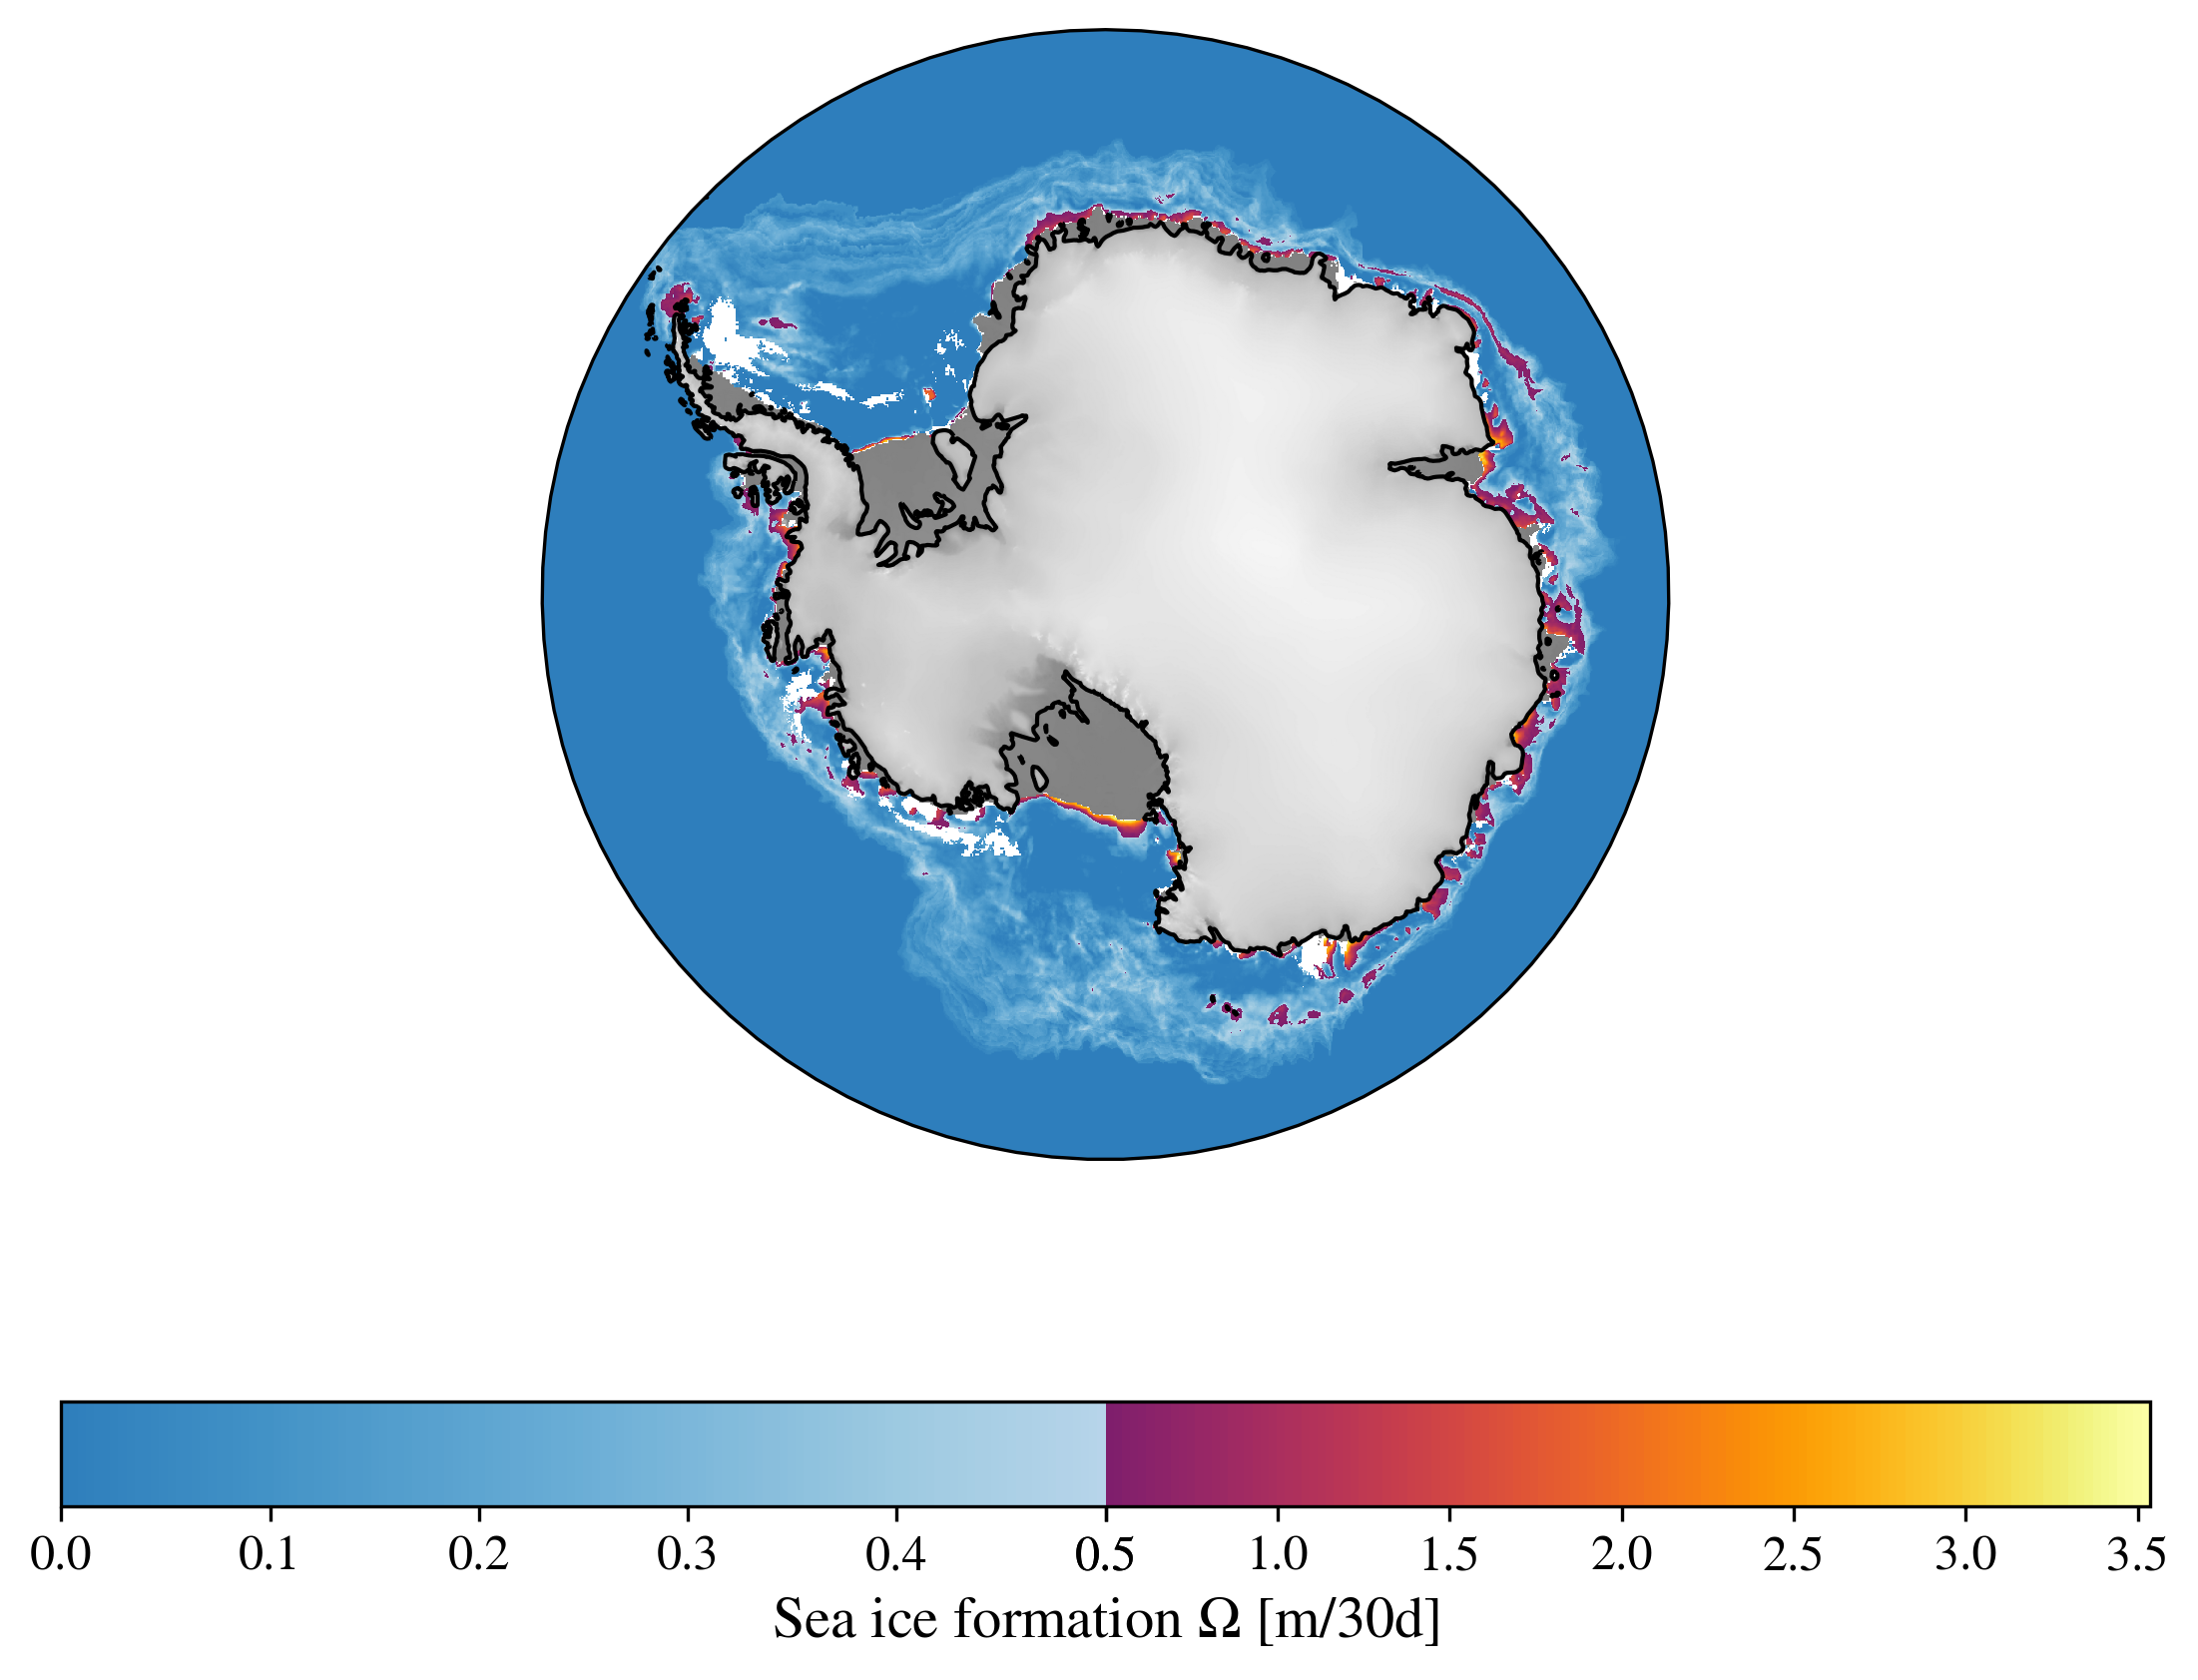

In [4]:
time = '2007-04-01T00:00:00.000000000' #selected month
fig, ax = prepare_plot_SO(dpi = 300)

cmap_bed = mcolors.ListedColormap(cm.binary(np.flip(np.linspace(0.025,0.5,100))))
divnorm_bed= mcolors.TwoSlopeNorm(vmin=0., vcenter=500, vmax=np.nanmax(Bedmachine.surface.values))
Bedmachine.surface.plot.pcolormesh(cmap=cmap_bed,add_colorbar=False, norm=divnorm_bed,shading='gouraud', infer_intervals=False)

# Define the sea ice formation rate colormap
colors1 = plt.cm.Blues_r(np.linspace(0.3, 0.7, 128))
colors2 = plt.cm.inferno(np.linspace(0.35, 1, 128))
colors = np.vstack((colors1, colors2))
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

# plot sea ice formation rates from Nakata et al 2021
divnorm=mcolors.TwoSlopeNorm(vmin=0., vcenter=0.5, vmax=np.nanmax(ice_prod_series["prod"].sel(time=time).values))
levels = np.concatenate((np.linspace(0,0.5,6),np.linspace(0.5,3.5,7)))
ice_prod_series["prod"].sel(time=time).plot.pcolormesh(ax=ax,
                                                       cmap=mymap, norm=divnorm,
                                                       cbar_kwargs={'location': 'bottom', 'ticks': levels, 'label': 'Sea ice formation '+r'$\Omega$'+' [m/30d]'})

# plot in white the masked data
mask_nodata = np.isnan(ice_prod_series["prod"].sel(time=time))*(np.logical_not(np.isnan(ice_prod_mean["prod"].sel(time='2007-06-16'))))
(mask_nodata).where(mask_nodata==True).plot.pcolormesh(add_colorbar=False,
                                                       cmap='binary',
                                                       vmin=1,vmax=100)

ax.set_title(None)

plt.savefig('Figure2/Antarctica.png', dpi=300)
plt.show()

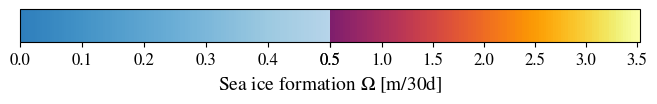

In [5]:
fig, ax = plt.subplots(figsize=(8, 1))
fig.subplots_adjust(bottom=0.55)

# Create a colorbar
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=mymap, norm=divnorm),
    cax=ax,
    orientation='horizontal',
    ticks=levels
)
cbar.set_label('Sea ice formation '+r'$\Omega$'+' [m/30d]')

# Show the plot
plt.savefig('Figure2/colorbar.pdf', bbox_inches='tight')
plt.show()

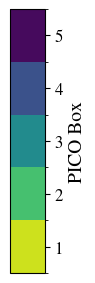

In [6]:
fig, ax = plt.subplots(figsize=(0.45, 8))
fig.subplots_adjust(bottom=0.55)

cmap = mcolors.ListedColormap(cm.viridis(np.flip(np.linspace(0.025,0.925,100))))
bounds = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)
# Create a colorbar
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap, norm=norm),
    cax=ax,
    orientation='vertical',
    ticks=np.arange(1,6)
)
cbar.set_label('PICO Box')

# Show the plot
plt.savefig('Figure2/colorbar_box.pdf', bbox_inches='tight')
plt.show()

### Defining ice shelves of interest

In [7]:
index_isf = np.array([10,11,31,52,66,43,45,48,33])
def index2name(N): #Convert isf index to isf name
    return IS_mask_Burgard.isf_name.sel(Nisf = N).values

name_isf =[]
for N in index_isf:
    name_isf.append(index2name(N))
name_isf = np.array(name_isf)
# ['Ross', 'Filchner-Ronne', 'Amery', 'Dotson', 'Pine Island', 'Thwaites', 'Riiser-Larsen', 'Roi Baudouin', 'Totten']

box_number = []
for N in index_isf:
    if N==52: # want to set nbox=2 for Dotson
        box_number.append(2)
    else:
        box_number.append(Box_1D_Burgard.nD_config.sel(Nisf=N).values[-1])
box_number = np.array(box_number)
# [5, 5, 3, 2, 2, 3, 3, 2]

### Define a function making scale bars

In [9]:
def scale_bar(length,xloc,yloc, adjustx=0):
    # Plot a scale bar
    
    xmin,xmax = ax.get_xlim()
    ymin,ymax = ax.get_ylim()

    xbar = [xmin+xloc*(xmax-xmin)-length/2,xmin+xloc*(xmax-xmin)+length/2]
    ybar = [ymin+yloc*(ymax-ymin),ymin+yloc*(ymax-ymin)]

    ax.plot(xbar, ybar, color='black', linewidth=2)
    # I commented the next line to add myself the text on the figures
    #ax.text(xmin+xloc*(xmax-xmin)+adjustx*(xmax-xmin),ymin+yloc*(ymax-ymin)+0.02*(ymax-ymin),str(int(round(length/1e3,0)))+ ' km')

### Define a function making insets plots

In [19]:
def plot_inset(indexes,time,latmin,latmax,lonmin,lonmax,figsize):
    """This function returns inset plots for Fig1.
    inputs:
        indexes: list of isf indexes we want to plot
        time: str indicating the month at which we want to plot the sea ice formation rate, e.g '2007-04-01T00:00:00.000000000'
        latmin, latmax, lonmin, lonmax: boudaries of the plotting domain
        figsize: figure size, e.g. (4,4)
    
    Usage:
        ax = plot_inset(indexes,time,latmin,latmax,lonmin,lonmax,figsize)
    """
    
    fig = plt.figure(figsize=figsize, dpi=200)
    ax = plt.axes(projection = ccrs.Stereographic(
    central_latitude=-90,
    central_longitude=0,
    true_scale_latitude=-71))

    ax.set_extent([lonmin, lonmax, latmin, latmax], ccrs.PlateCarree().as_geodetic())
    gl = ax.gridlines(draw_labels=False)
    gl.xlines = False

    gl.ylines = False


    # plot bedmachine
    cmap_bed = mcolors.ListedColormap(cm.binary(np.flip(np.linspace(0,0.3,100))))
    divnorm_bed=mcolors.TwoSlopeNorm(vmin=0., vcenter=500, vmax=np.nanmax(Bedmachine.surface.values))
    Bedmachine.surface.plot.pcolormesh(cmap=cmap_bed,add_colorbar=False, norm=divnorm_bed,shading='gouraud', infer_intervals=False)

    cmap_IS_zoom = mcolors.ListedColormap(cm.binary(0.5))
    IS_mask_Burgard.ISF_mask.where(IS_mask_Burgard.ISF_mask>1).plot(add_colorbar=False, cmap=cmap_IS_zoom)

    # plot PICO box delimitations from Burgard et al 2022
    cmap_boxes = mcolors.ListedColormap(cm.viridis(np.flip(np.linspace(0.025,0.925,100))))
    for index in indexes:
        Box_2D_Burgard.box_location.sel(box_nb_tot=box_number[np.argwhere(index_isf==index)[0][0]]).where(IS_mask_Burgard.ISF_mask==index).plot.pcolormesh(add_colorbar=False, cmap=cmap_boxes, vmin=1,vmax=5)

    # plot sea ice formation rates from Nakata et al 2021
    divnorm=mcolors.TwoSlopeNorm(vmin=0., vcenter=0.5, vmax=np.nanmax(ice_prod_mean["prod"].values))
    ice_prod_series["prod"].sel(time=time).plot.pcolormesh(cmap=mymap, norm=divnorm, add_colorbar=False)

    # plot in white the masked data
    mask_nodata = np.isnan(ice_prod_series["prod"].sel(time=time))*(np.logical_not(np.isnan(ice_prod_mean["prod"].sel(time='2007-06-16'))))
    mask_nodata.where(mask_nodata==True).plot.pcolormesh(add_colorbar=False,cmap='binary',vmin=1,vmax=100)

    ax.set_title(None)
    return ax

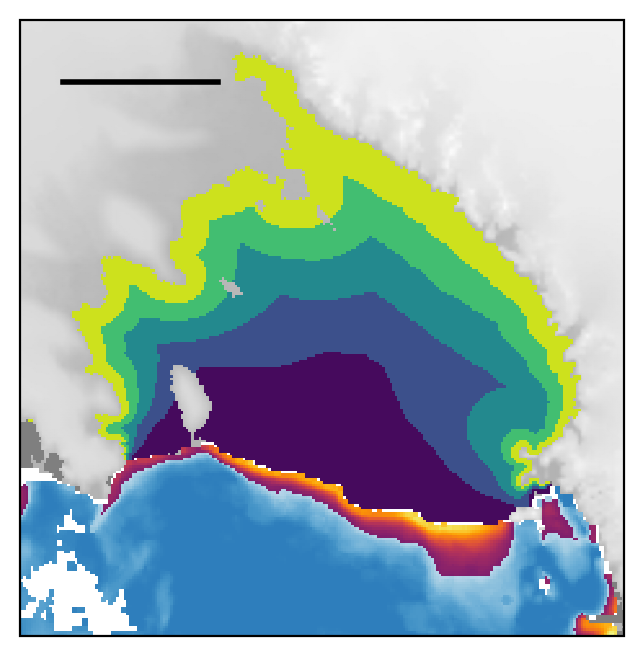

In [20]:
#ross
time = '2007-04-01T00:00:00.000000000' #selected month
indexes = [10]
lon = IS_mask_Burgard.longitude.where(IS_mask_Burgard.ISF_mask == indexes[0])
lat = IS_mask_Burgard.latitude.where(IS_mask_Burgard.ISF_mask == indexes[0])
latmin = np.nanmin(lat) - 0.1*(np.nanmax(lat)-np.nanmin(lat))
latmax = np.nanmax(lat) + 0.3*(np.nanmax(lat)-np.nanmin(lat))
lonmin = -155
lonmax = 163
figsize = (4,4)

ax = plot_inset(indexes,time,latmin,latmax,lonmin,lonmax,figsize)
scale_bar(300e3,0.2,0.9,adjustx=-0.08)
plt.savefig('Figure2/Ross.png', dpi=300)
plt.show()

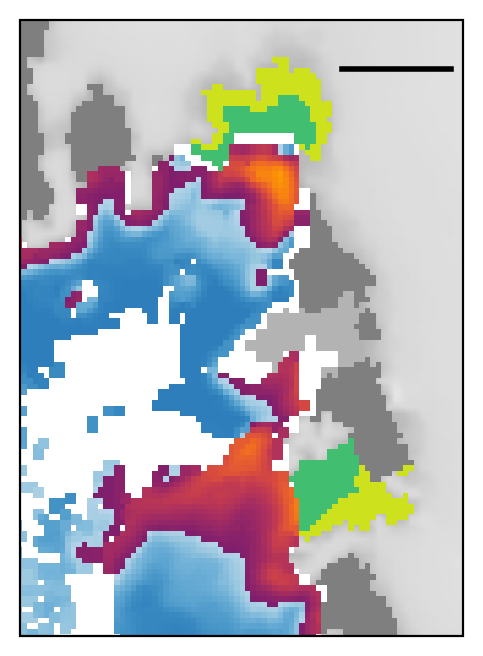

In [21]:
#West Antarctica
time = '2007-04-01T00:00:00.000000000' #selected month
indexes = [52,66]
latmin = -73
latmax = -75.5
lonmin = -98
lonmax = -115
figsize = (4,4)

ax = plot_inset(indexes,time,latmin,latmax,lonmin,lonmax,figsize)
scale_bar(100e3,0.85,0.92,adjustx=-0.12)
plt.savefig('Figure2/West_Antarctica.png', dpi=300)
plt.show()

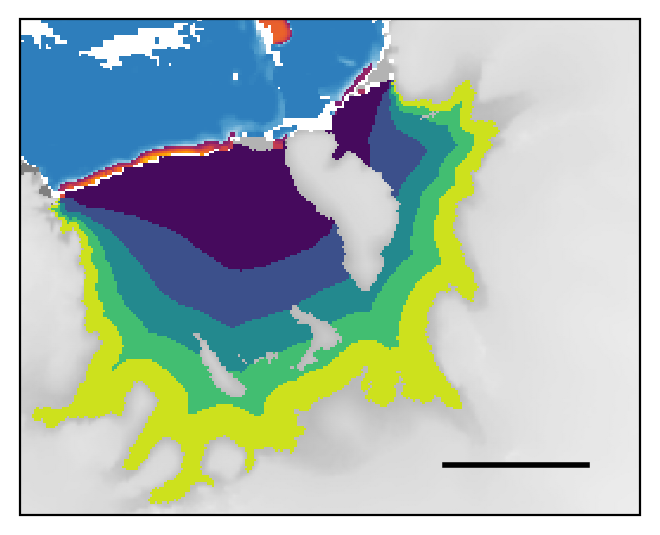

In [35]:
#Fichner-Ronne
time = '2007-04-01T00:00:00.000000000' #selected month
indexes = [11]
latmin = -75
latmax = -87
lonmin = -70
lonmax = -45
figsize = (4,4)

ax = plot_inset(indexes,time,latmin,latmax,lonmin,lonmax,figsize)
scale_bar(300e3,0.8,0.1,adjustx=-0.08)
plt.savefig('Figure2/Filchner-Ronne.png', dpi=300)
plt.show()

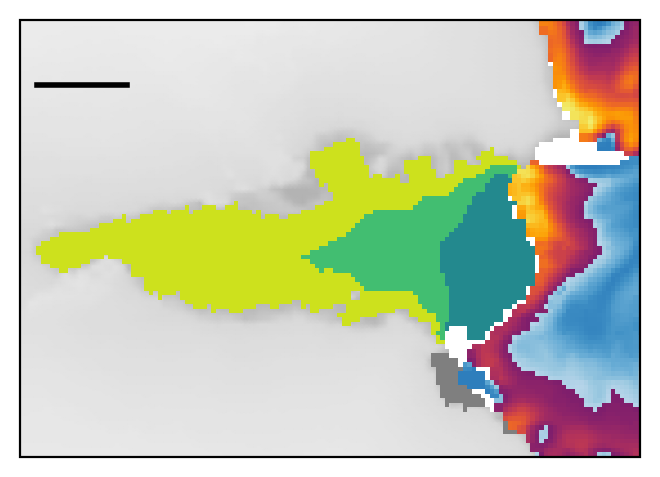

In [23]:
#Amery
time = '2007-04-01T00:00:00.000000000' #selected month
indexes = [31]
lon = IS_mask_Burgard.longitude.where(IS_mask_Burgard.ISF_mask == indexes[0])
lat = IS_mask_Burgard.latitude.where(IS_mask_Burgard.ISF_mask == indexes[0])
latmin = np.nanmin(lat) - 0.03*(np.nanmax(lat)-np.nanmin(lat))
latmax = np.nanmax(lat) + 0.15*(np.nanmax(lat)-np.nanmin(lat))
lonmin = np.nanmin(lon) - 0.03*(np.nanmax(lon)-np.nanmin(lon))
lonmax = np.nanmax(lon) + 0.03*(np.nanmax(lon)-np.nanmin(lon))
figsize = (4,4)

ax = plot_inset(indexes,time,latmin,latmax,lonmin,lonmax,figsize)
scale_bar(100e3,0.1,0.85,adjustx=-0.08)
plt.savefig('Figure2/Amery.png', dpi=300)
plt.show()

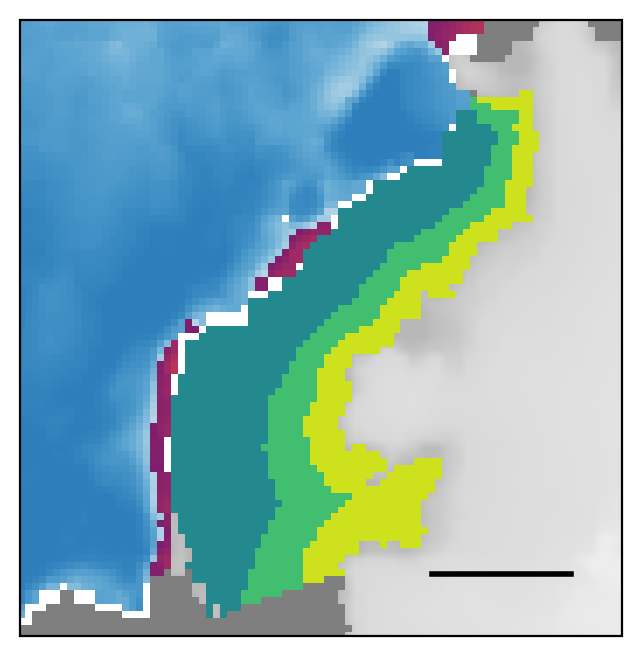

In [24]:
#Riiser-Larsen
time = '2007-04-01T00:00:00.000000000' #selected month
indexes = [43]
lon = IS_mask_Burgard.longitude.where(IS_mask_Burgard.ISF_mask == indexes[0])
lat = IS_mask_Burgard.latitude.where(IS_mask_Burgard.ISF_mask == indexes[0])
latmin = np.nanmin(lat) - 0.03*(np.nanmax(lat)-np.nanmin(lat))
latmax = np.nanmax(lat) + 0.15*(np.nanmax(lat)-np.nanmin(lat))
lonmin = np.nanmin(lon) - 0.03*(np.nanmax(lon)-np.nanmin(lon))
lonmax = np.nanmax(lon) + 0.03*(np.nanmax(lon)-np.nanmin(lon))
figsize = (4,4)

ax = plot_inset(indexes,time,latmin,latmax,lonmin,lonmax,figsize)
scale_bar(100e3,0.8,0.1,adjustx=-0.08)
plt.savefig('Figure2/Riiser-Larsen.png', dpi=300)
plt.show()

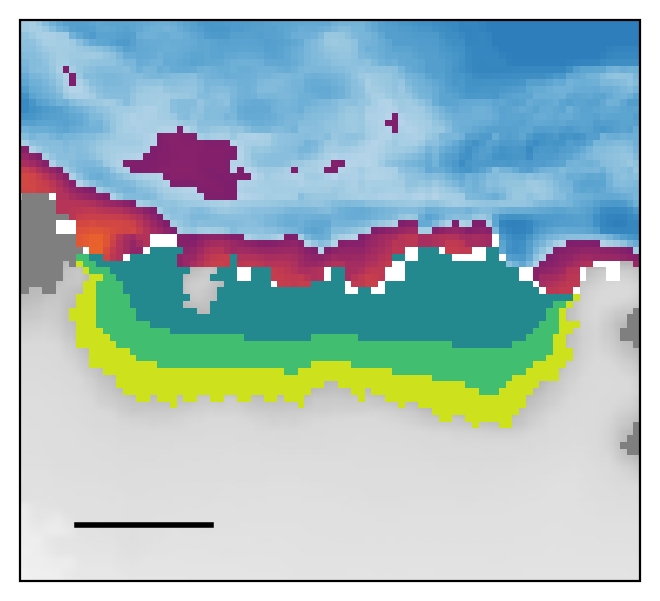

In [25]:
#Roi Baudouin
time = '2007-04-01T00:00:00.000000000' #selected month
indexes = [45]
lon = IS_mask_Burgard.longitude.where(IS_mask_Burgard.ISF_mask == indexes[0])
lat = IS_mask_Burgard.latitude.where(IS_mask_Burgard.ISF_mask == indexes[0])
latmin = np.nanmin(lat) - 0.03*(np.nanmax(lat)-np.nanmin(lat))
latmax = np.nanmax(lat) + 0.15*(np.nanmax(lat)-np.nanmin(lat))
lonmin = np.nanmin(lon) - 0.03*(np.nanmax(lon)-np.nanmin(lon))
lonmax = np.nanmax(lon) + 0.03*(np.nanmax(lon)-np.nanmin(lon))
figsize = (4,4)

ax = plot_inset(indexes,time,latmin,latmax,lonmin,lonmax,figsize)
scale_bar(100e3,0.2,0.1,adjustx=-0.08)
plt.savefig('Figure2/Roi_Baudouin.png', dpi=300)
plt.show()

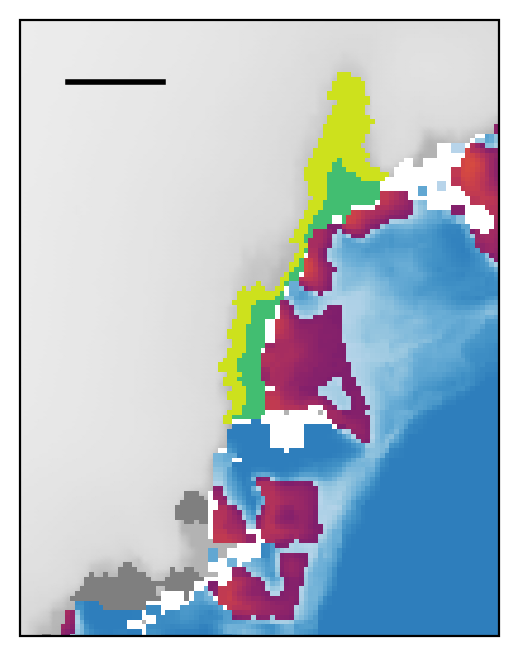

In [26]:
#Totten and Moscow Univ
time = '2007-04-01T00:00:00.000000000' #selected month
indexes = [48,33]
latmin = -68
latmax = -66
lonmin = 113
lonmax = 127
figsize = (4,4)

ax = plot_inset(indexes,time,latmin,latmax,lonmin,lonmax,figsize)
scale_bar(100e3,0.2,0.9,adjustx=-0.1)
plt.savefig('Figure2/Totten_Moscow.png', dpi=300)
plt.show()